In [4]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import  AerSimulator
from qiskit.quantum_info import Operator
from qiskit.visualization import plot_histogram

In [23]:
def phase_oracle(n, indices_to_mark, name='Oracle'):
    qc = QuantumCircuit(n, name=name)
    oracle_matrix = np.identity(2**n)
    for index_to_mark in indices_to_mark:
        oracle_matrix[index_to_mark, index_to_mark] *= -1

    qc.unitary(Operator(oracle_matrix), range(n))
    return qc

In [24]:
def diffuser(n):
    qc = QuantumCircuit(n, name='Diffuser')
    qc.h(range(n))
    qc.append(phase_oracle(n, [0], name='Zero-Oracle'), range(n))
    qc.h(range(n))
    return qc

In [25]:
def grover_circuit(n, indices_to_mark, num_iterations):
    qc = QuantumCircuit(n, n)
 
    qc.h(range(n))   # step 1: |0...0> -> |s>
 
    for _ in range(num_iterations):
        qc.append(phase_oracle(n, indices_to_mark), range(n))
        qc.append(diffuser(n), range(n))

    qc.measure(range(n),range(n))
    return qc
    

In [27]:
n = 4
target_index = [11]          #11 is integer, converted to 4 bit string
M = len(target_index)
N = 2**n
num_iterations = int(np.floor((np.pi / 4) * np.sqrt(N / M)))
qc = grover_circuit(n, target_index, num_iterations)

In [28]:
qc.draw()

┌───┐┌─────────┐┌───────────┐┌─────────┐┌───────────┐┌─────────┐»
q_0: ┤ H ├┤0        ├┤0          ├┤0        ├┤0          ├┤0        ├»
     ├───┤│         ││           ││         ││           ││         │»
q_1: ┤ H ├┤1        ├┤1          ├┤1        ├┤1          ├┤1        ├»
     ├───┤│  Oracle ││  Diffuser ││  Oracle ││  Diffuser ││  Oracle │»
q_2: ┤ H ├┤2        ├┤2          ├┤2        ├┤2          ├┤2        ├»
     ├───┤│         ││           ││         ││           ││         │»
q_3: ┤ H ├┤3        ├┤3          ├┤3        ├┤3          ├┤3        ├»
     └───┘└─────────┘└───────────┘└─────────┘└───────────┘└─────────┘»
c: 4/════════════════════════════════════════════════════════════════»
                                                                     »
«     ┌───────────┐┌─┐         
«q_0: ┤0          ├┤M├─────────
«     │           │└╥┘┌─┐      
«q_1: ┤1          ├─╫─┤M├──────
«     │  Diffuser │ ║ └╥┘┌─┐   
«q_2: ┤2          ├─╫──╫─┤M├───
«     │           │ ║  ║ └╥┘┌─┐
«q_3: ┤3          ├─╫──╫──╫─┤M├
«     └───────────┘ ║  ║  ║ └╥┘
«c: 4/══════════════╩══╩══╩══╩═
«                   0  1  2  3

In [32]:
n = 4
target_index = [11]          #11 is integer, converted to 4 bit string
M = len(target_index)
N = 2**n
num_iterations = int(np.floor((np.pi / 4) * np.sqrt(N / M)))
qc = grover_circuit(n, target_index, num_iterations)
qc = qc.decompose().decompose()

simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

In [33]:
print(counts)

{'1100': 1, '1101': 2, '1011': 989, '0111': 2, '0011': 1, '1000': 3, '0110': 4, '1111': 3, '0001': 4, '1110': 3, '0000': 2, '0010': 5, '0101': 2, '1001': 1, '0100': 1, '1010': 1}


In [20]:
plot_histograms(counts)

NameError: name 'plot_histograms' is not defined

In [21]:
qc.draw()

global phase: 2.2377
     ┌────────────┐ ┌───────────────┐          ┌───────────────────┐         »
q_0: ┤ U(π/2,0,π) ├─┤ U(π,3π/4,π/4) ├────■─────┤ U(π,1.448,3.0188) ├──────■──»
     ├────────────┤┌┴───────────────┴─┐┌─┴─┐┌──┴───────────────────┴───┐┌─┴─┐»
q_1: ┤ U(π/2,0,π) ├┤ U(0.15207,π/2,0) ├┤ X ├┤ U(1.5822,1.6288,-1.9587) ├┤ X ├»
     ├────────────┤└───┬─────────┬────┘└───┘└──────────────────────────┘└───┘»
q_2: ┤ U(π/2,0,π) ├────┤ Rz(π/8) ├───────────────────────────────────────────»
     ├────────────┤    ├─────────┴┐                                          »
q_3: ┤ U(π/2,0,π) ├────┤ Rz(-π/8) ├──────────────────────────────────────────»
     └────────────┘    └──────────┘                                          »
c: 4/════════════════════════════════════════════════════════════════════════»
                                                                             »
«     ┌──────────────────────┐                                      »
«q_0: ┤ U(0,-1.7802,-1.7541) ├──■────────────────────────────────■──»
«     ├─────────────────────┬┘  │                                │  »
«q_1: ┤ U(1.4187,-π/8,-π/2) ├───┼────────────────■───────────────┼──»
«     └─────────────────────┘ ┌─┴─┐┌──────────┐┌─┴─┐┌─────────┐┌─┴─┐»
«q_2: ────────────────────────┤ X ├┤ Rz(-π/8) ├┤ X ├┤ Rz(π/8) ├┤ X ├»
«                             └───┘└──────────┘└───┘└─────────┘└───┘»
«q_3: ──────────────────────────────────────────────────────────────»
«                                                                   »
«c: 4/══════════════════════════════════════════════════════════════»
«                                                                   »
«                                                                       »
«q_0: ──────────────■────────────────────────────────■──────────────────»
«                   │                                │                  »
«q_1: ──────────────┼───────■───────■────────────────┼──────────────────»
«     ┌──────────┐  │     ┌─┴─┐     │                │                  »
«q_2: ┤ Rz(-π/8) ├──┼─────┤ X ├─────┼────────────────┼───────────────■──»
«     └──────────┘┌─┴─┐┌──┴───┴──┐┌─┴─┐┌──────────┐┌─┴─┐┌─────────┐┌─┴─┐»
«q_3: ────────────┤ X ├┤ Rz(π/8) ├┤ X ├┤ Rz(-π/8) ├┤ X ├┤ Rz(π/8) ├┤ X ├»
«                 └───┘└─────────┘└───┘└──────────┘└───┘└─────────┘└───┘»
«c: 4/══════════════════════════════════════════════════════════════════»
«                                                                       »
«                                                                       »
«q_0: ─────────────■────────────────────────────────■───────────────────»
«                  │                                │                   »
«q_1: ─────────────┼────────────────■───────────────┼───────────────────»
«                  │                │               │                   »
«q_2: ─────────────┼────────────────┼───────────────┼────────────────■──»
«     ┌─────────┐┌─┴─┐┌──────────┐┌─┴─┐┌─────────┐┌─┴─┐┌──────────┐┌─┴─┐»
«q_3: ┤ Rz(π/8) ├┤ X ├┤ Rz(-π/8) ├┤ X ├┤ Rz(π/8) ├┤ X ├┤ Rz(-π/8) ├┤ X ├»
«     └─────────┘└───┘└──────────┘└───┘└─────────┘└───┘└──────────┘└───┘»
«c: 4/══════════════════════════════════════════════════════════════════»
«                                                                       »
«                             ┌────────────┐              ┌──────────┐»
«q_0: ──────■──────────────■──┤ U(π/2,0,π) ├──────────────┤0         ├»
«           │              │  └────────────┘┌────────────┐│          │»
«q_1: ──────┼─────────■────┼────────■───────┤ U(π/2,0,π) ├┤1         ├»
«         ┌─┴─┐     ┌─┴─┐┌─┴─┐    ┌─┴─┐     ├────────────┤│  Unitary │»
«q_2: ────┤ X ├─────┤ X ├┤ X ├────┤ X ├─────┤ U(π/2,0,π) ├┤2         ├»
«     ┌───┴───┴────┐└───┘└───┘    └───┘     └────────────┘│          │»
«q_3: ┤ U(π/2,0,π) ├──────────────────────────────────────┤3         ├»
«     └────────────┘                                      └──────────┘»
«c: 4/══════════════════════════════════════════════════════════

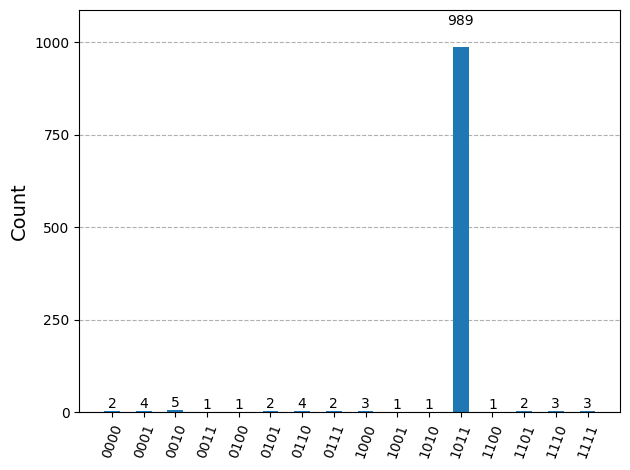

In [34]:
from qiskit.visualization import plot_histogram

plot_histogram(counts)